# Live capital simulator - protected BTC strategy
Replays the protected strategy over a chosen date range and simulates **your account**:

1. trade BTC from a start date to an end date
2. **Scenario A** - one initial lump sum
3. **Scenario B** - initial + a regular **monthly payment** (dollar-cost-averaging into the strategy)
4. reporting + an animated live equity chart vs buy & hold
5. **Ruin analysis** - shows the leverage at which one bad bar liquidates your whole account

Uses the same protected strategy as the live trader (`protected_strategy.protected_pnl_series`).
All results are historical & idealized - read the caveats at the end.

## 1. Setup

In [1]:
import os, sys, time, json, datetime as dt
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
os.chdir(r"C:\Users\sliso\BTC_Live")
for m in ['strategy_patterns','strategy_funnel','test_single_strategy','indicators_loader','protected_strategy']:
    sys.modules.pop(m, None)
import strategy_funnel as sf
import protected_strategy as ps
print("ready | trend filter", ps.USE_TREND, "MA", ps.MA_WIN, "| target_vol", ps.TARGET_ANN_VOL)

ready | trend filter True MA 300 | target_vol 0.12


## 2. Config - YOUR scenario

In [7]:
CSV          = "BTCUSDT_1h.csv"
START_DATE   = "2024-07-01"     # trade from
END_DATE     = None             # trade to (None = end of data); e.g. "2026-01-01"
INITIAL      = 50          # initial capital (USD)
MONTHLY      = 50           # monthly payment for Scenario B (USD); 0 = none
LEVERAGE     = 5           # leverage to simulate
ANNUAL_DRAG  = 0.05            # extra annual cost (funding + slippage buffer), e.g. 0.05 = 5%/yr
FRAMES       = 60
PPY          = 8760.0


print(f"BTC {START_DATE}->{END_DATE or 'end'} | initial ${INITIAL:.0f} | monthly ${MONTHLY:.0f} | "
      f"leverage {LEVERAGE}x | drag {ANNUAL_DRAG:.0%}/yr")

BTC 2024-07-01->end | initial $50 | monthly $50 | leverage 5x | drag 5%/yr


## 3. Compute the protected strategy P&L over the window

In [9]:
df = sf.load_ohlc(CSV)
base_pnl, net, dates = ps.protected_pnl_series(df, "2026-01-01", "2026-06-22")
n = len(base_pnl); years = n/PPY
# BTC per-bar returns aligned EXACTLY to `dates` (same length as base_pnl) for buy & hold
cw = df['Close'].reindex(dates).values.astype(float)
btc_ret = np.zeros(n); btc_ret[1:] = cw[1:]/cw[:-1] - 1.0
print(f"{n:,} bars ({years:.2f}y)  {dates[0]:%Y-%m-%d} -> {dates[-1]:%Y-%m-%d} | "
      f"worst single bar (1x): {base_pnl.min()*100:.2f}%")

4,080 bars (0.47y)  2026-01-01 -> 2026-06-19 | worst single bar (1x): -0.39%


## 4. Account simulator (lump sum and/or monthly contributions, with liquidation)

In [10]:
def simulate(pnl, dates, leverage, initial, monthly, annual_drag=0.0):
    n=len(pnl)
    factors = 1.0 + leverage*pnl - leverage*annual_drag/PPY     # per-bar growth incl. drag
    months = pd.Series(dates).dt.to_period('M').values
    is_contrib = np.zeros(n, bool); is_contrib[1:] = months[1:] != months[:-1]
    eq=np.zeros(n); cc=np.zeros(n); bal=float(initial); total=float(initial); liq=None
    for i in range(n):
        if monthly>0 and is_contrib[i]:
            bal += monthly; total += monthly
        f = factors[i]
        bal = bal*f if f>0 else 0.0                              # f<=0 => liquidation -> 0
        if f <= 0 and liq is None: liq = dates[i]
        eq[i]=bal; cc[i]=total
    return dict(equity=eq, contrib=cc, total_contributed=total, final=float(eq[-1]),
                liquidated_at=liq, factors=factors)

def maxdd(eq):
    pk=np.maximum.accumulate(eq); return float(np.max((pk-eq)/np.where(pk>0,pk,1)))

A = simulate(base_pnl, dates, LEVERAGE, INITIAL, 0.0, ANNUAL_DRAG)                 # lump sum
B = simulate(base_pnl, dates, LEVERAGE, INITIAL, MONTHLY, ANNUAL_DRAG)             # + monthly
bhA = simulate(btc_ret, dates, 1.0, INITIAL, 0.0, 0.0)                             # buy&hold lump
bhB = simulate(btc_ret, dates, 1.0, INITIAL, MONTHLY, 0.0)                         # buy&hold DCA
print("simulated.")

simulated.


## 5. Reporting

In [11]:
def report(name, sim, leverage):
    eq=sim['equity']; tc=sim['total_contributed']; fin=sim['final']
    prof=fin-tc; roi=prof/tc if tc>0 else 0
    cagr=(fin/INITIAL)**(1/years)-1 if (INITIAL>0 and fin>0 and sim['contrib'][-1]==INITIAL) else np.nan
    return {'scenario':name, 'leverage':f"{leverage}g".replace('g','x'),
            'contributed':round(tc,0), 'final':round(fin,0), 'profit':round(prof,0),
            'ROI_on_contrib':f"{roi*100:.0f}%", 'max_drawdown':f"{maxdd(eq)*100:.0f}%",
            'liquidated':('YES @ '+str(sim['liquidated_at'].date()) if sim['liquidated_at'] else 'no')}
rows=[report(f"A: lump ${INITIAL:.0f}", A, LEVERAGE),
      report(f"B: lump+${MONTHLY:.0f}/mo", B, LEVERAGE),
      report("buy&hold lump", bhA, 1.0),
      report("buy&hold DCA", bhB, 1.0)]
display(pd.DataFrame(rows).set_index('scenario'))

,leverage,contributed,final,profit,ROI_on_contrib,max_drawdown,liquidated
scenario,,,,,,,
A: lump $50,5x,50.0,72.0,22.0,44%,9%,no
B: lump+$50/mo,5x,300.0,370.0,70.0,23%,9%,no
buy&hold lump,1.0x,50.0,36.0,-14.0,-28%,39%,no
buy&hold DCA,1.0x,300.0,255.0,-45.0,-15%,20%,no


## 6. Animated live chart - both scenarios vs buy & hold

=== Account simulation  initial $50 + $50/mo  2026-06-19 UTC  bar 4080/4080  leverage 5x ===
strategy $370  | contributed $300  | buy&hold $255  | drawdown now 3% max 9%


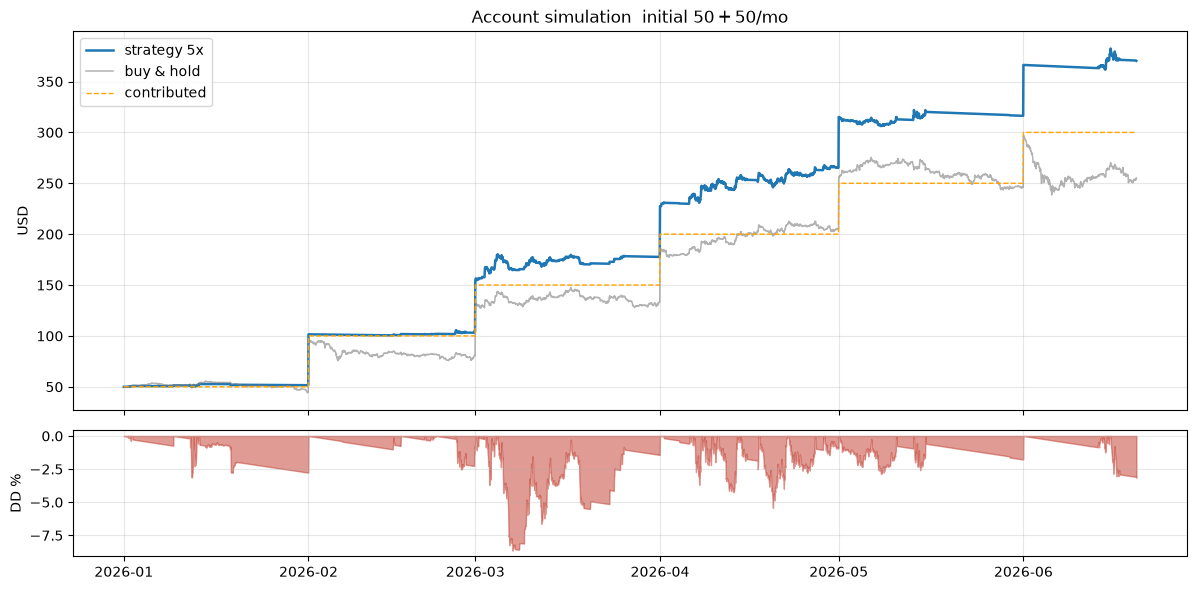

In [12]:
def animate(simS, simBH, title, monthly):
    e=simS['equity']; b=simBH['equity']; c=simS['contrib']
    pk=np.maximum.accumulate(e); dd=(pk-e)/np.where(pk>0,pk,1)
    def frame(k):
        x=dates[:k]
        print(f"=== {title}  {x[-1]:%Y-%m-%d} UTC  bar {k}/{n}  leverage {LEVERAGE}x ===")
        print(f"strategy ${e[:k][-1]:,.0f}  | contributed ${c[:k][-1]:,.0f}  | "
              f"buy&hold ${b[:k][-1]:,.0f}  | drawdown now {dd[:k][-1]:.0%} max {dd[:k].max():.0%}"
              + ("  ** LIQUIDATED **" if e[:k][-1]<=0 else ""))
        fig,ax=plt.subplots(2,1,figsize=(12,6),sharex=True,gridspec_kw={'height_ratios':[3,1]})
        ax[0].plot(x,e[:k],lw=1.8,label=f'strategy {LEVERAGE}x')
        ax[0].plot(x,b[:k],lw=1.1,alpha=.6,color='gray',label='buy & hold')
        if monthly>0: ax[0].plot(x,c[:k],lw=1.0,ls='--',color='orange',label='contributed')
        ax[0].legend(loc='upper left'); ax[0].set_ylabel("USD"); ax[0].grid(alpha=.3)
        ax[0].set_title(title)
        ax[1].fill_between(x,-dd[:k]*100,0,color='#c0392b',alpha=.5); ax[1].set_ylabel("DD %"); ax[1].grid(alpha=.3)
        plt.tight_layout(); plt.show()
    step=max(1,n//FRAMES)
    for k in range(step,n+1,step):
        clear_output(wait=True); frame(k); time.sleep(0.05)
    clear_output(wait=True); frame(n)

# choose which scenario to animate: B (with monthly) if MONTHLY>0 else A
animate(B if MONTHLY>0 else A, bhB if MONTHLY>0 else bhA,
        f"Account simulation  initial ${INITIAL:.0f}" + (f" + ${MONTHLY:.0f}/mo" if MONTHLY>0 else ""),
        MONTHLY)

## 7. RUIN ANALYSIS - can higher leverage wipe you out?
A single bar that loses more than 1/leverage liquidates the whole account. The strategy's worst
single 1x bar sets the **critical leverage** = -1 / worst_bar. Above it, you would have been
fully liquidated at least once.

In [8]:
worst = float(base_pnl.min())
crit = (-1.0/worst) if worst < 0 else float('inf')
print(f"In-sample worst single bar (protected, 1x): {worst*100:.2f}%  ->  in-sample critical leverage ~{crit:.0f}x")
print("This number is OPTIMISTIC: the trend filter dodged past crashes. The REAL ruin risk is a")
print("future flash crash while you are leveraged-long. A bar moving -(1/leverage) wipes you out.")

print("LIQUIDATION THRESHOLD - the single adverse bar that wipes each leverage:")
for L in [2,3,5,10,20,50]:
    move = 1.0/L
    seen = "BTC HAS had hourly moves this big in crashes" if move <= 0.10 else "rare in 1h, but possible"
    print(f"  {L:>2}x  ->  a -{move*100:.0f}% bar liquidates EVERYTHING   ({seen})")
print()

rows=[]
for L in [1,2,3,5,10,20]:
    s = simulate(base_pnl, dates, L, INITIAL, 0.0, ANNUAL_DRAG)
    risk = 'low' if L<=3 else ('HIGH' if L>=10 else 'medium')
    rows.append({'leverage':f"{L}x", 'final_$':round(s['final'],0),
                 'x_initial':round(s['final']/INITIAL,1) if INITIAL>0 else None,
                 'in_sample_maxDD':f"{maxdd(s['equity'])*100:.0f}%",
                 'flash_crash_ruin_risk':risk})
display(pd.DataFrame(rows).set_index('leverage'))
print("NOTE: real exchanges liquidate at maintenance margin (BEFORE -100%), so true thresholds are LOWER.")
print("In-sample 'no liquidation' at high leverage is survivorship - do NOT trust it.")
print("Prudent crypto ceiling: 2-3x. Monthly contributions do NOT protect against liquidation.")

In-sample worst single bar (protected, 1x): -0.39%  ->  in-sample critical leverage ~256x
This number is OPTIMISTIC: the trend filter dodged past crashes. The REAL ruin risk is a
future flash crash while you are leveraged-long. A bar moving -(1/leverage) wipes you out.
LIQUIDATION THRESHOLD - the single adverse bar that wipes each leverage:
   2x  ->  a -50% bar liquidates EVERYTHING   (rare in 1h, but possible)
   3x  ->  a -33% bar liquidates EVERYTHING   (rare in 1h, but possible)
   5x  ->  a -20% bar liquidates EVERYTHING   (rare in 1h, but possible)
  10x  ->  a -10% bar liquidates EVERYTHING   (BTC HAS had hourly moves this big in crashes)
  20x  ->  a -5% bar liquidates EVERYTHING   (BTC HAS had hourly moves this big in crashes)
  50x  ->  a -2% bar liquidates EVERYTHING   (BTC HAS had hourly moves this big in crashes)



,final_$,x_initial,in_sample_maxDD,flash_crash_ruin_risk
leverage,,,,
1x,108.0,1.1,2%,low
2x,116.0,1.2,4%,low
3x,125.0,1.3,5%,low
5x,144.0,1.4,9%,medium
10x,202.0,2.0,17%,HIGH
20x,365.0,3.6,31%,HIGH


NOTE: real exchanges liquidate at maintenance margin (BEFORE -100%), so true thresholds are LOWER.
In-sample 'no liquidation' at high leverage is survivorship - do NOT trust it.
Prudent crypto ceiling: 2-3x. Monthly contributions do NOT protect against liquidation.


## Caveats (read before believing any number)
- **Idealized.** Includes trading cost + a flat drag for funding/slippage, but real fills, real
  funding spikes (bull markets), and gaps will make live results worse.
- **In-sample optimism.** The protected strategy's high Sharpe is an upper bound; treat returns as
  optimistic, drawdowns as lower bounds.
- **Liquidation is simplified.** Real exchanges liquidate at a maintenance margin BEFORE -100%, so
  the true critical leverage is LOWER than shown. Stay well under it.
- **Monthly DCA does not prevent ruin** at high leverage - it just feeds a wiped account. Risk
  control is leverage, not contributions.